In [1]:
import pandas as pd

df = pd.read_csv('train_and_test2.csv')

In [2]:
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [3]:
df.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.13      1309

In [5]:
colunas_zero = df.columns[df.columns.astype(str).str.contains('zero')]

In [8]:
colunas_zero

Index(['zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6',
       'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12',
       'zero.13', 'zero.14', 'zero.15', 'zero.16', 'zero.17', 'zero.18'],
      dtype='str')

In [9]:
df_limpo = df.drop(columns = colunas_zero)

In [10]:
df_limpo.head()

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,2urvived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0


In [15]:
df_limpo.corr()['2urvived'].sort_values(ascending=False)

2urvived       1.000000
Sex            0.404020
Fare           0.173786
Parch          0.054908
sibsp         -0.014375
Age           -0.055862
Embarked      -0.093225
Pclass        -0.244686
Passengerid   -0.331493
Name: 2urvived, dtype: float64

In [16]:
df_limpo.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   Parch        1309 non-null   int64  
 6   Pclass       1309 non-null   int64  
 7   Embarked     1307 non-null   float64
 8   2urvived     1309 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 92.2 KB


In [29]:
df_limpo.rename(columns = {'2urvived':'Survived'}, inplace = True)

In [35]:
df_class= df_limpo[['Pclass','Survived','Passengerid']].groupby(['Pclass','Survived']).count().reset_index().pivot(index='Pclass',columns='Survived',values='Passengerid')

In [37]:
df_class['total_passageiros'] = df_class[0] + df_class[1]

In [39]:
df_class['pct_sobreviventes'] = df_class[1] / df_class['total_passageiros']

In [40]:
df_class

Survived,0,1,total_passageiros,pct_sobreviventes
Pclass,,,,
1,187,136,323,0.421053
2,190,87,277,0.314079
3,590,119,709,0.167842


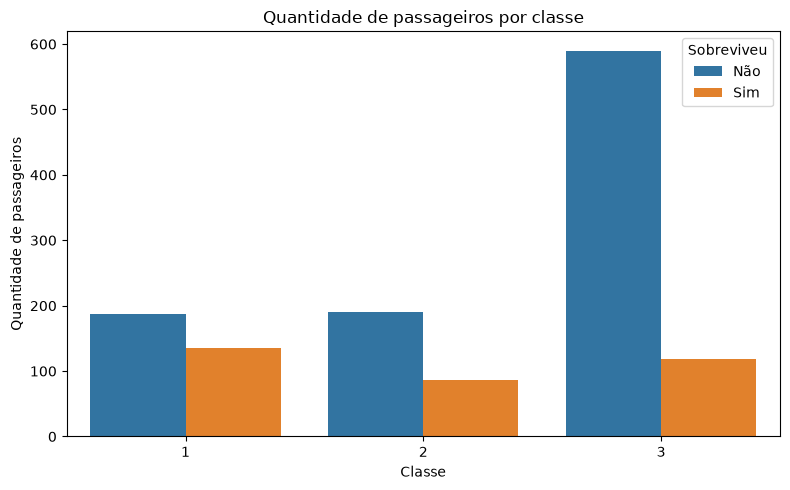

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_limpo,
    x="Pclass",
    hue="Survived"
)

plt.title("Quantidade de passageiros por classe")
plt.xlabel("Classe")
plt.ylabel("Quantidade de passageiros")
plt.legend(
    title="Sobreviveu",
    labels=["Não", "Sim"]
)

plt.tight_layout()
plt.show()

Pclass é determinante na sobrevivência

In [41]:
df_limpo.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass',
       'Embarked', 'Survived'],
      dtype='str')

In [42]:
df_limpo['Fare'].describe()

count    1309.000000
mean       33.281086
std        51.741500
min         0.000000
25%         7.895800
50%        14.454200
75%        31.275000
max       512.329200
Name: Fare, dtype: float64

<Axes: xlabel='Fare'>

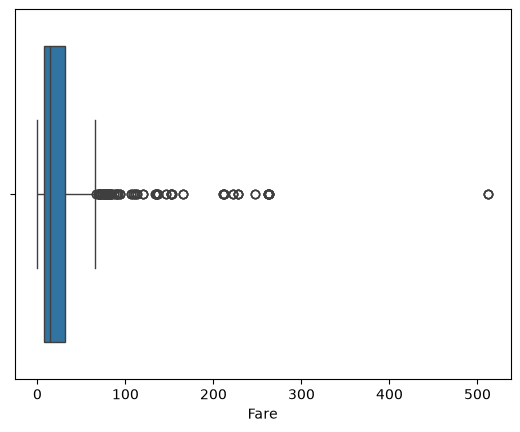

In [43]:
sns.boxplot(
    data=df_limpo,
    x="Fare"
)

<Axes: xlabel='Fare', ylabel='Pclass'>

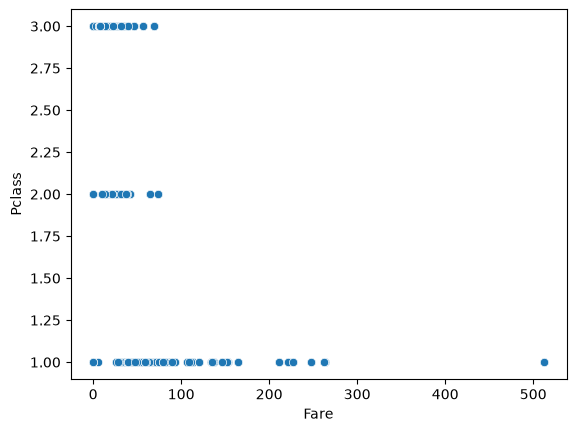

In [45]:
sns.scatterplot(df_limpo, x='Fare', y='Pclass')

Ho= O quanto foi pago no ticket influência na sobrevivência

In [48]:
from scipy.stats import mannwhitneyu    


fare_survived = df_limpo.loc[df_limpo['Survived'] == 1, 'Fare'].dropna()
fare_no_survived = df_limpo.loc[df_limpo['Survived'] == 0, 'Fare'].dropna()

estatistica, p_valor= mannwhitneyu(fare_survived, fare_no_survived, alternative = "two-sided")

print(f"Estatística U: {estatistica:.2f}")
print(f"P-valor: {p_valor:.6f}")

if p_valor < 0.05:
    print("Rejeitamos H₀: Fare difere entre os grupos.")
else:
    print("Não rejeitamos H₀.")


Estatística U: 217906.00
P-valor: 0.000000
Rejeitamos H₀: Fare difere entre os grupos.


In [49]:
fare_survived = df_limpo.loc[df_limpo['Survived'] == 1, 'Fare'].dropna()
fare_no_survived = df_limpo.loc[df_limpo['Survived'] == 1, 'Pclass'].dropna()

estatistica, p_valor= mannwhitneyu(fare_survived, fare_no_survived, alternative = "two-sided")

print(f"Estatística U: {estatistica:.2f}")
print(f"P-valor: {p_valor:.6f}")

if p_valor < 0.05:
    print("Rejeitamos H₀: Fare difere entre os grupos.")
else:
    print("Não rejeitamos H₀.")


Estatística U: 116622.00
P-valor: 0.000000
Rejeitamos H₀: Fare difere entre os grupos.


O quanto foi pago na passagem difere na sobrevivência